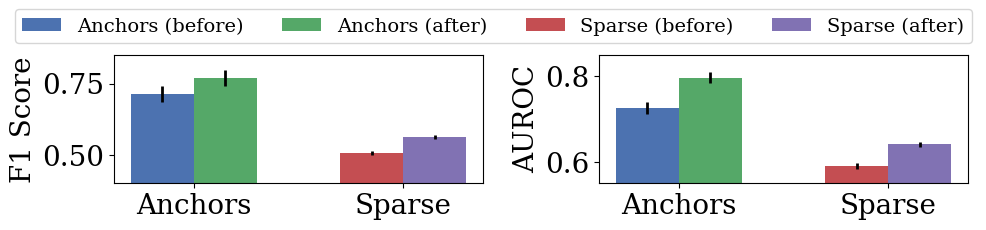

In [81]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 20,           # base font size
    "axes.titlesize": 20,      # subplot title
    "axes.labelsize": 20,      # x/y labels
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

# ------------------------------
# Houston data
# ------------------------------
f1_anchors_before = (0.71247, 0.02851)
f1_anchors_after  = (0.76938, 0.02794)
f1_sparse_before  = (0.50615, 0.00759)
f1_sparse_after   = (0.56191, 0.00813)

auc_anchors_before = (0.72622, 0.01489)
auc_anchors_after  = (0.79687, 0.01257)
auc_sparse_before  = (0.59066, 0.00762)
auc_sparse_after   = (0.64155, 0.00586)

labels = ["Anchors", "Sparse"]
x = np.arange(len(labels))
width = 0.30

color_anchor_before = "#4C72B0"
color_anchor_after  = "#55A868"
color_sparse_before = "#C44E52"
color_sparse_after  = "#8172B3"

fig, axs = plt.subplots(1, 2, figsize=(10, 2.5), sharey=False)

# ---------------- F1 subplot ----------------
ax = axs[0]
ax.bar(x[0] - width/2, f1_anchors_before[0], width,
       yerr=f1_anchors_before[1], label="Anchors (before)",
       color=color_anchor_before)
ax.bar(x[0] + width/2, f1_anchors_after[0], width,
       yerr=f1_anchors_after[1], label="Anchors (after)",
       color=color_anchor_after)

ax.bar(x[1] - width/2, f1_sparse_before[0], width,
       yerr=f1_sparse_before[1], label="Sparse (before)",
       color=color_sparse_before)
ax.bar(x[1] + width/2, f1_sparse_after[0], width,
       yerr=f1_sparse_after[1], label="Sparse (after)",
       color=color_sparse_after)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.4, 0.85)
ax.set_ylabel("F1 Score")
#ax.set_title("F1")

# ---------------- AUROC subplot ----------------
ax = axs[1]
ax.bar(x[0] - width/2, auc_anchors_before[0], width,
       yerr=auc_anchors_before[1], label="Anchors (before)",
       color=color_anchor_before)
ax.bar(x[0] + width/2, auc_anchors_after[0], width,
       yerr=auc_anchors_after[1], label="Anchors (after)",
       color=color_anchor_after)

ax.bar(x[1] - width/2, auc_sparse_before[0], width,
       yerr=auc_sparse_before[1], label="Sparse (before)",
       color=color_sparse_before)
ax.bar(x[1] + width/2, auc_sparse_after[0], width,
       yerr=auc_sparse_after[1], label="Sparse (after)",
       color=color_sparse_after)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.55, 0.85)
ax.set_ylabel("AUROC")
#ax.set_title("AUROC")

# Unified figure title
#fig.suptitle("Houston Open-Hours Prediction: Effect of Distribution Transfer", fontsize=18)

# Legend on top
handles, labels_legend = axs[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc="upper center", ncol=4, fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.90])  # leave space for top legend + suptitle
plt.show()

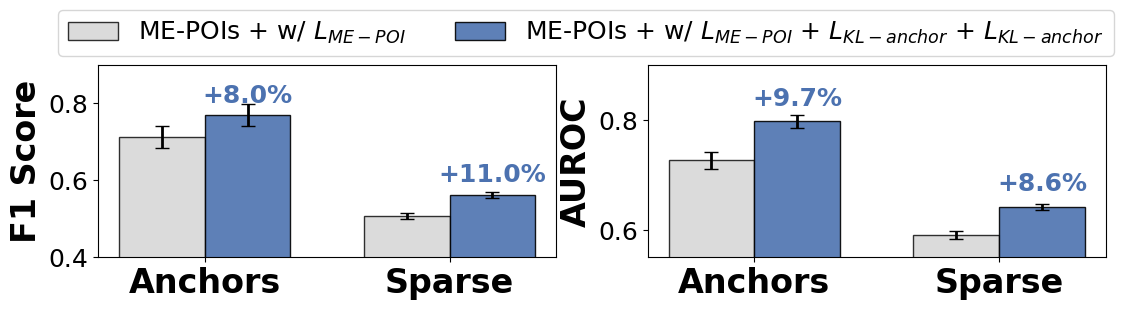

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Set publication-quality style
plt.rcParams.update({
    #"font.family": "serif",      # Matches LaTeX/Paper font
    "font.size": 28,
    "axes.titlesize": 28,
    "axes.labelsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "lines.linewidth": 2
})

# ------------------------------
# Data
# ------------------------------
# Format: (Mean, Error)
f1_anchors_before = (0.71247, 0.02851)
f1_anchors_after  = (0.76938, 0.02794)
f1_sparse_before  = (0.50615, 0.00759)
f1_sparse_after   = (0.56191, 0.00813)

auc_anchors_before = (0.72622, 0.01489)
auc_anchors_after  = (0.79687, 0.01257)
auc_sparse_before  = (0.59066, 0.00762)
auc_sparse_after   = (0.64155, 0.00586)

# ------------------------------
# Plotting Config
# ------------------------------
labels = ["Anchors", "Sparse"]
x = np.arange(len(labels))
width = 0.35  # Slightly wider bars for readability

# Use just TWO colors for clarity:
# One for "No Transfer", One for "With Transfer"
color_before = "#D3D3D3"  # Light Grey (Baseline)
color_after  = "#4C72B0"  # Blue (Your Method)

fig, axs = plt.subplots(1, 2, figsize=(13, 2.5))

# --- Helper Function to Plot ---
def plot_bars(ax, data_before, data_after, ylabel):
    # Extract means and errors
    means_before = [data_before[0][0], data_before[1][0]]
    errs_before  = [data_before[0][1], data_before[1][1]]
    
    means_after  = [data_after[0][0], data_after[1][0]]
    errs_after   = [data_after[0][1], data_after[1][1]]
    
    # Plot bars
    rects1 = ax.bar(x - width/2, means_before, width, yerr=errs_before, 
                    label="ME-POIs + w/ $L_{ME-POI}$", color=color_before, capsize=5, edgecolor='black', alpha=0.8)
    rects2 = ax.bar(x + width/2, means_after, width, yerr=errs_after, 
                    label="ME-POIs + w/ $L_{ME-POI}$ + $L_{KL-anchor}$ + $L_{KL-anchor}$", color=color_after, capsize=5, edgecolor='black', alpha=0.9)
    
    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold')
    #ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add % gain text on top of the 'After' bar
    for i, (m_b, m_a) in enumerate(zip(means_before, means_after)):
        gain = ((m_a - m_b) / m_b) * 100
        ax.text(x[i] + width/2, m_a + 0.020, f"+{gain:.1f}%", 
                ha='center', va='bottom', fontsize=18, fontweight='bold', color=color_after)

# --- Subplot 1: F1 Score ---
plot_bars(axs[0], [f1_anchors_before, f1_sparse_before], 
                  [f1_anchors_after, f1_sparse_after], "F1 Score")
axs[0].set_ylim(0.4, 0.90)
#axs[0].set_title("Performance by POI Type (F1)")

# --- Subplot 2: AUROC ---
plot_bars(axs[1], [auc_anchors_before, auc_sparse_before], 
                  [auc_anchors_after, auc_sparse_after], "AUROC")
axs[1].set_ylim(0.55, 0.90)
#axs[1].set_title("Performance by POI Type (AUROC)")

# --- Unified Legend ---
# We only need the legend from one subplot since colors are consistent
handles, legend_labels = axs[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper center", ncol=2, 
           bbox_to_anchor=(0.5, 1.15), frameon=True, fontsize=18)

#plt.tight_layout(rect=[0, 0, 1, 0.92]) # Adjust for legend space
#plt.show()

plt.savefig("ablation_study_results.pdf", format="pdf", bbox_inches="tight", dpi=300)

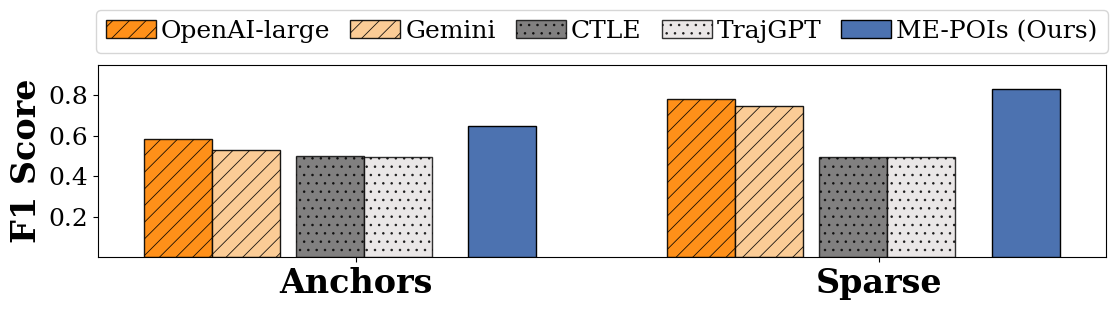

In [137]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURATION (MATCHING YOUR REFERENCE) ---
plt.rcParams.update({
    #"font.family": "serif",      # Uncomment if using serif in paper
    "font.size": 28,
    "axes.titlesize": 28,
    "axes.labelsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,        # Matched to your reference code's fig.legend size
    "lines.linewidth": 2
})

# --- 2. DATA ---
# Format: (Anchor_Score, Sparse_Score)
txt1 = (0.586, 0.782) 
txt2 = (0.527, 0.748)
mob1 = (0.500, 0.493) 
mob2 = (0.493, 0.494) 
me_pois = (0.648, 0.829)

# --- 3. PLOTTING FUNCTION ---
def plot_results(ax, metric_name, t1, t2, m1, m2, me):
    labels = ["Anchors", "Sparse"]
    x = np.arange(len(labels))
    width = 0.13
    
    # --- COLORS ---
    c_txt1 = "#FF8400"  # Dusty Red
    c_txt2 = "#FBC78B"  # Salmon
    c_mob1 = "#626161"  # Slate Grey
    c_mob2 = "#E5E2E2"  # Light Grey
    c_me   = "#4C72B0"  # Deep Royal Blue

    # --- OFFSETS ---
    pos_t1 = x - 0.34
    pos_t2 = x - 0.21
    pos_m1 = x - 0.05
    pos_m2 = x + 0.08
    pos_me = x + 0.28

    # --- DRAW BARS ---
    # Text Group
    ax.bar(pos_t1, t1, width, label='OpenAI-large', color=c_txt1, 
           edgecolor='black', hatch='//', alpha=0.9)
    ax.bar(pos_t2, t2, width, label='Gemini', color=c_txt2, 
           edgecolor='black', hatch='//', alpha=0.9)
    
    # Mobility Group
    ax.bar(pos_m1, m1, width, label='CTLE', color=c_mob1, 
           edgecolor='black', hatch='..', alpha=0.8)
    ax.bar(pos_m2, m2, width, label='TrajGPT', color=c_mob2, 
           edgecolor='black', hatch='..', alpha=0.8)
    
    # ME-POIs Group
    ax.bar(pos_me, me, width, label='ME-POIs (Ours)', color=c_me, 
           edgecolor='black', zorder=3)

    # --- FORMATTING ---
    ax.set_ylabel(metric_name, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontweight='bold')
    
    # Force Y-ticks to match the style of your other plot
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_ylim(0, 0.95) # Slightly higher to fit 0.8 comfortably

# --- 4. GENERATE PLOT ---
# Exact size match: (13, 2.5)
fig, ax = plt.subplots(figsize=(13, 2.5)) 

plot_results(ax, "F1 Score", txt1, txt2, mob1, mob2, me_pois)

# --- LEGEND ---
# Using the same style and roughly the same position
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.35), 
          ncol=5, frameon=True, 
          handletextpad=0.2, columnspacing=0.8, fontsize=18)

plt.savefig("ablation_study_results_comparison_w_models.pdf", format="pdf", bbox_inches="tight", dpi=300)
# plt.show()